In [9]:
from scapyter.domain.correlation.cpa_correlation import CpaCorrelation
from scapyter.domain.correlation.cpa_service import CorrelationTask
from scapyter.domain.leakage.leakage import SboxOutputLeakageModel
from scapyter.domain.value_object import RangeParameters, Range, DataSource, KeyByteGuesses
from scapyter.ui.correlation_plotter import CorrelationPlotter
from scapyter.ui.key_rank_visualizer import KeyRankVisualizer
from scapyter.infrastructure.h5_trace_repository import H5TraceRepository

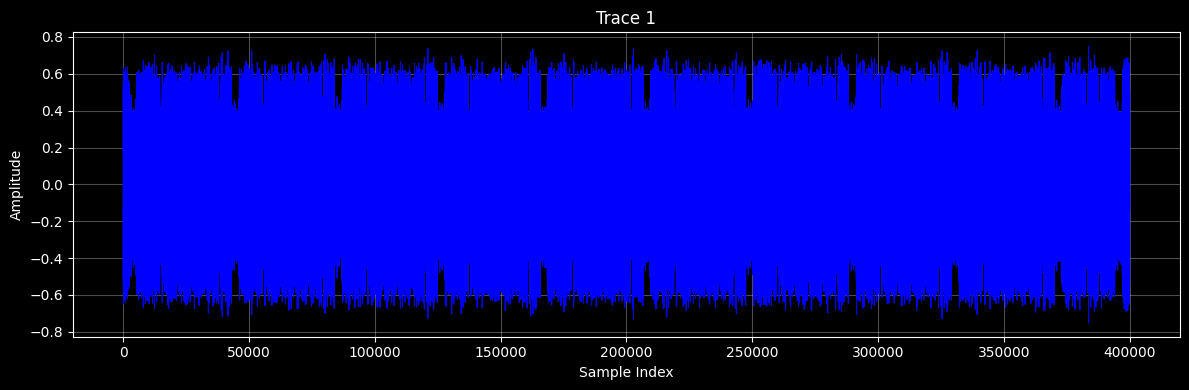

In [10]:
from scapyter.ui.trace_plotter import TracePlotter

file_path = "data/smart-card-project/smart_card_project.sx"

trace_repo = H5TraceRepository(file_path)
trace_plotter = TracePlotter(trace_repo)
trace_plotter.plot_single(index=1)

In [11]:
range_parameter = RangeParameters(
    trace_range=Range(0, 125),
    trace_sample_range=Range(14000, 44000),
)

leakage_model = SboxOutputLeakageModel()

results = []
for i in range(16):
    snr = CpaCorrelation()
    key_byte_guesses = KeyByteGuesses.with_correct_and_random_key_bytes(correct_key_byte=i, num_random_key_bytes=5)
    result = CorrelationTask(
        byte_location=i,
        range_parameters=range_parameter,
        leakage_model=leakage_model,
        correlation=snr,
        trace_repository=trace_repo,
        data_source=DataSource.PLAINTEXT,
        key_byte_guesses=key_byte_guesses,

    ).run()
    results.append(result)

In [12]:
visualizer = KeyRankVisualizer(results)

# 2. Display the table
# This will show the top 5 candidates for every byte
visualizer.display_rank_table(top_n=5)

# 3. Print the final guessed key hex string
guessed_key = visualizer.get_full_key_guess()
print(f"Guessed Key: {guessed_key.hex().upper()}")

,Byte 00,Byte 01,Byte 02,Byte 03,Byte 04,Byte 05,Byte 06,Byte 07,Byte 08,Byte 09,Byte 10,Byte 11,Byte 12,Byte 13,Byte 14,Byte 15
Rank 1,00 (0.779),01 (0.615),02 (0.613),03 (0.897),04 (0.806),05 (0.743),06 (0.620),07 (0.820),08 (0.830),09 (0.725),0A (0.691),0B (0.692),0C (0.871),0D (0.544),0E (0.648),0F (0.889)
Rank 2,CE (0.356),E4 (0.313),47 (0.300),CE (0.359),97 (0.302),B2 (0.343),63 (0.310),DE (0.328),A2 (0.375),02 (0.339),02 (0.285),8D (0.404),F8 (0.302),46 (0.346),B5 (0.393),10 (0.347)
Rank 3,5F (0.267),0D (0.277),8E (0.296),6F (0.344),F8 (0.284),F8 (0.322),9E (0.298),27 (0.313),C1 (0.344),D1 (0.328),90 (0.276),54 (0.329),F2 (0.292),DB (0.307),F2 (0.338),C2 (0.313)
Rank 4,30 (0.253),56 (0.273),F8 (0.285),C9 (0.336),D3 (0.273),FA (0.307),17 (0.274),0B (0.309),B6 (0.334),D0 (0.295),84 (0.262),7D (0.285),4B (0.286),75 (0.287),4C (0.334),72 (0.292)
Rank 5,AA (0.250),A1 (0.256),88 (0.264),67 (0.289),01 (0.270),EF (0.297),CE (0.261),13 (0.296),1F (0.328),E8 (0.277),EA (0.247),58 (0.258),67 (0.278),D4 (0.287),F6 (0.276),13 (0.289)


Guessed Key: 000102030405060708090A0B0C0D0E0F


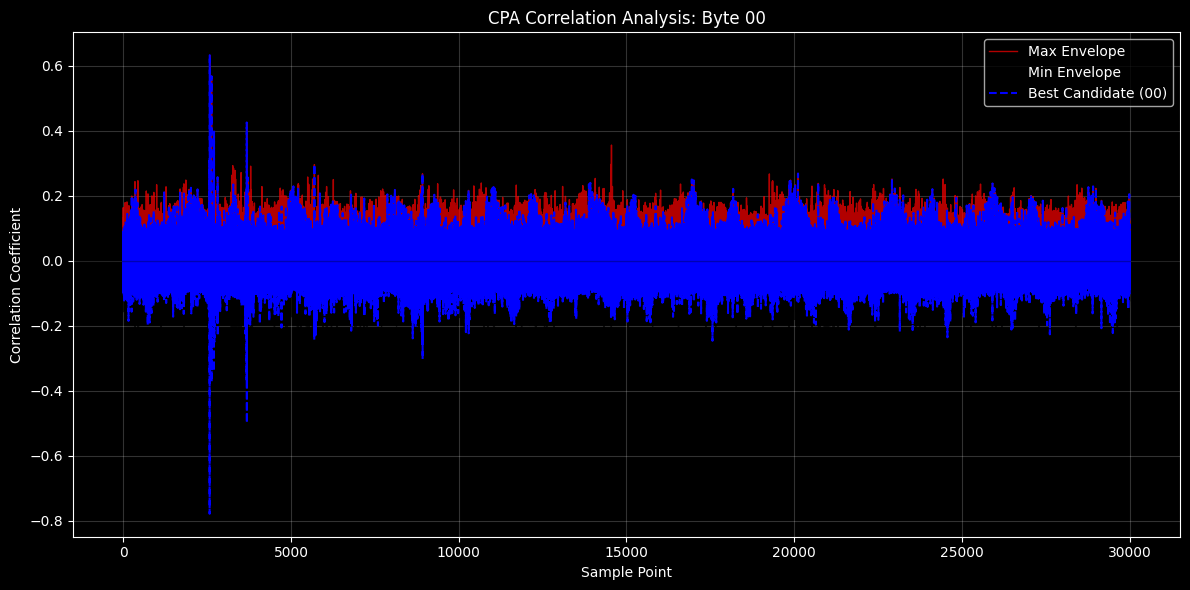

In [13]:
plotter = CorrelationPlotter(results)
plotter.plot(0)

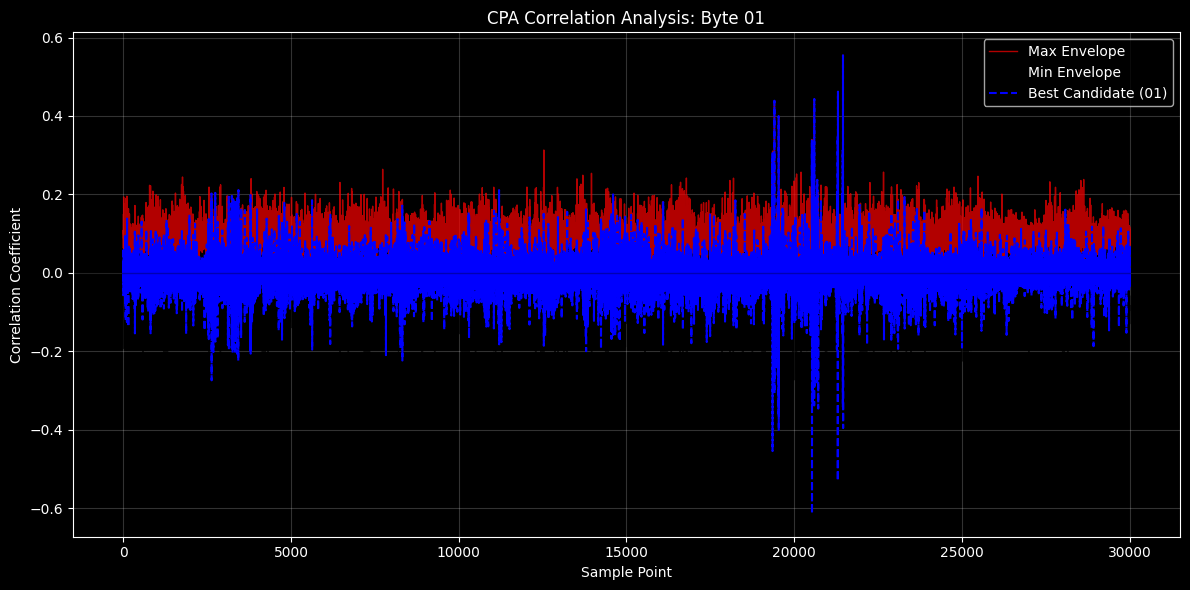

In [14]:
plotter.plot(1)

In [15]:
from scapyter.domain.snr.snr_task import SnrTask
from scapyter.domain.snr.snr import ProgressiveSnr
trace_sample_range = Range(14000, 44000)
range_parameter = RangeParameters(
    trace_range=Range(0, 125),
    trace_sample_range=trace_sample_range,
)

leakage_model = SboxOutputLeakageModel()

results = []
for i in range(16):
    snr = ProgressiveSnr()
    result = SnrTask(
        byte_location=i,
        range_parameters=range_parameter,
        leakage_model=leakage_model,
        snr=snr,
        trace_repository=trace_repo,
        data_source=DataSource.PLAINTEXT,
        known_key_byte=i
    ).run()
    results.append((i, result))

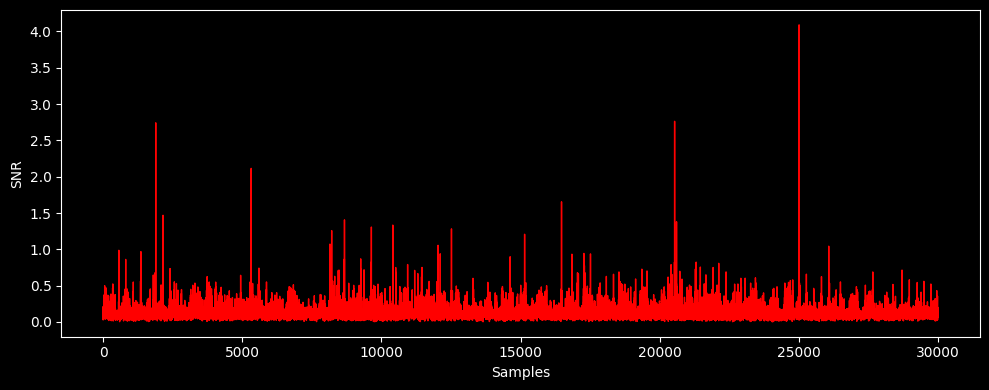

In [16]:
from scapyter.ui.snr_plotter import SnrPlotter

plotter = SnrPlotter(results[1])
plotter.plot()